In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import scipy
eps_double = np.finfo(float).eps


In [2]:
%run Streaming_DMD_functions.ipynb

### FIG. 8a)

- $x_0 = [-0.7, 0.1, 0.1], \Delta t = 10^{-3}$

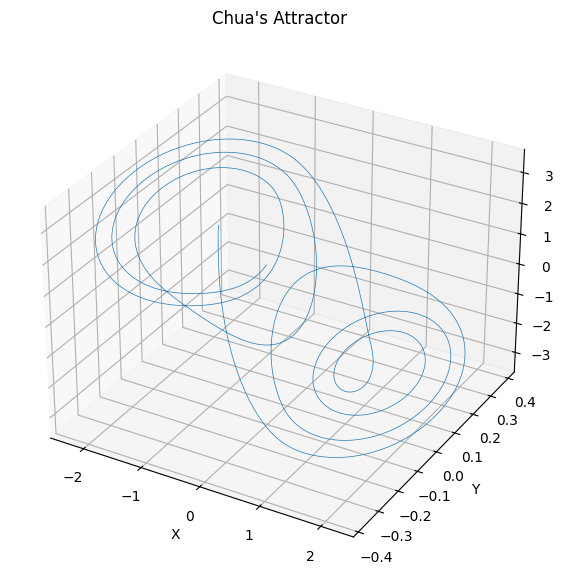

In [3]:
## SIMULATION OF CHUA SYSTEM - code adjusted from https://chuacircuits.com/matlab/

def chua_system(t, state, alpha, beta, m0, m1):  
    x, y, z = state
    
    h = m1 * x + 0.5 * (m0 - m1) * (np.abs(x + 1) - np.abs(x - 1))
    
    xdot = alpha * (y - x - h)
    ydot = x - y + z
    zdot = -beta * y
    
    return [xdot, ydot, zdot]

alpha = 15.6
beta = 28
m0 = -1.143
m1 = -0.714

t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 10000)   
initial_state = [-0.7, 0.1, 0.1]

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [4]:
#####################################################################################################
q = 100
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)



for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 

    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))



C:\Users\elawi\AppData\Local\Temp\ipykernel_26088\1784361255.py:35: LinAlgWarning: Ill-conditioned matrix (rcond=3.95451e-17): result may not be accurate.
  Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")


(1e-14, 10.0)

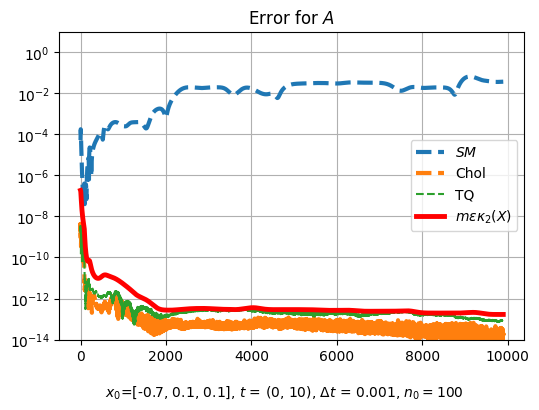

In [5]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e1)

### FIG 8b)

- $x_0 = [-0.7, 0.1, 0.1], \Delta t = 10^{-4}$

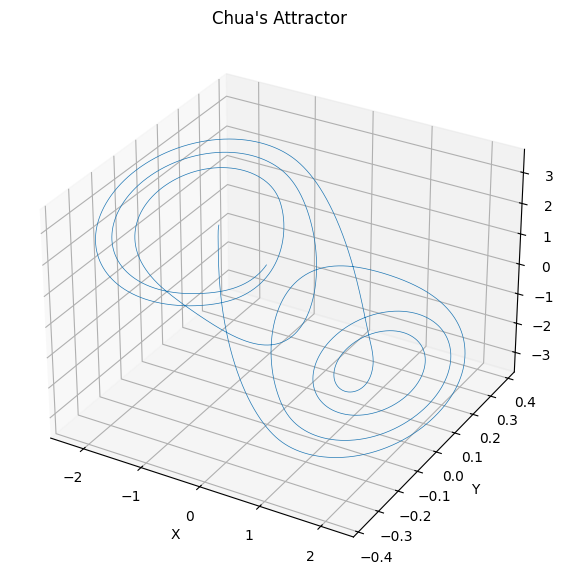

In [6]:
t_eval = np.linspace(t_span[0], t_span[1], 100000)   

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [7]:
#####################################################################################################
q = 100
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = np.linalg.pinv(Gx)

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)



for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 

    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))



(1e-14, 10.0)

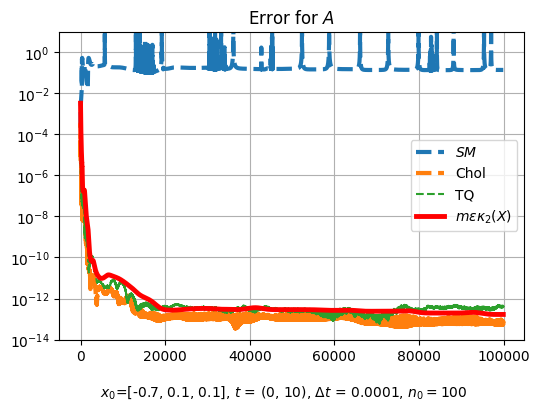

In [8]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e1)

### FIG 8c)

- $x_0 = [-10.7, 0, 0], \Delta t = 10^{-3}, t_{max}=30$

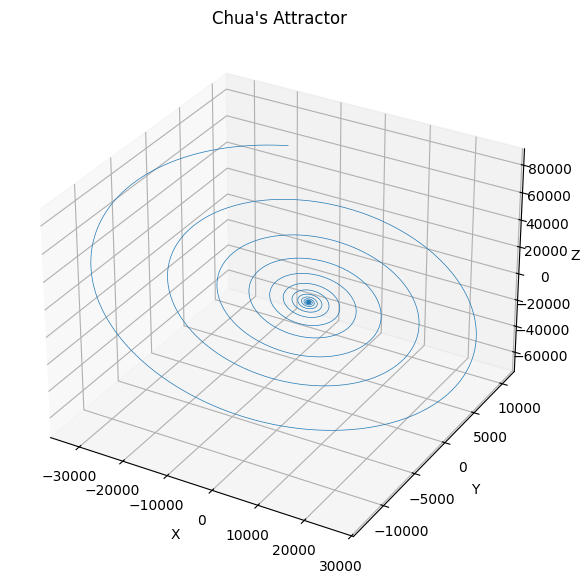

In [9]:
t_span=(0,30)
t_eval = np.linspace(t_span[0], t_span[1], 30000)   
initial_state = [-10.7, 0, 0]

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [10]:
#####################################################################################################
q = 100
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)

for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 
    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))


(1e-14, 10.0)

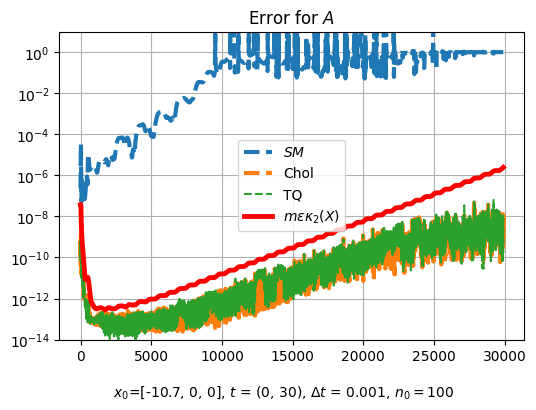

In [11]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e1)

### FIG. 9a)

- $x_0 = [-10.7, 0, 0], $\Delta t = 10^{-3}, t_{max} = 30, n_0 = 250$

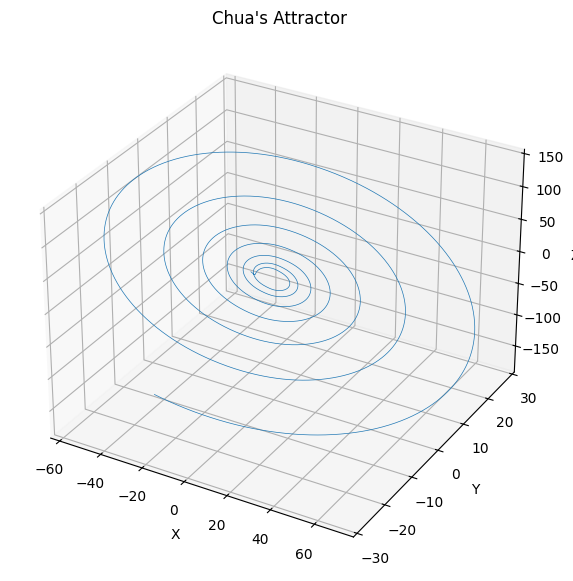

In [12]:
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 10000)   

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [13]:
#####################################################################################################
q = 250
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)



for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 

    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))



(1e-14, 10.0)

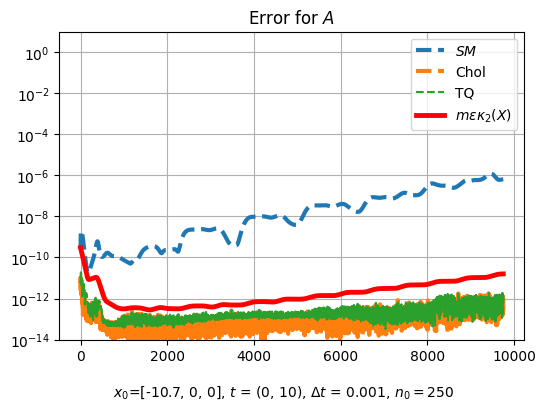

In [14]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e1)

### FIG. 9b)

- $x_0 = [-10.7, 0, 0], \Delta t = 10^{-3}, t_{max} = 70, n_0 =100$

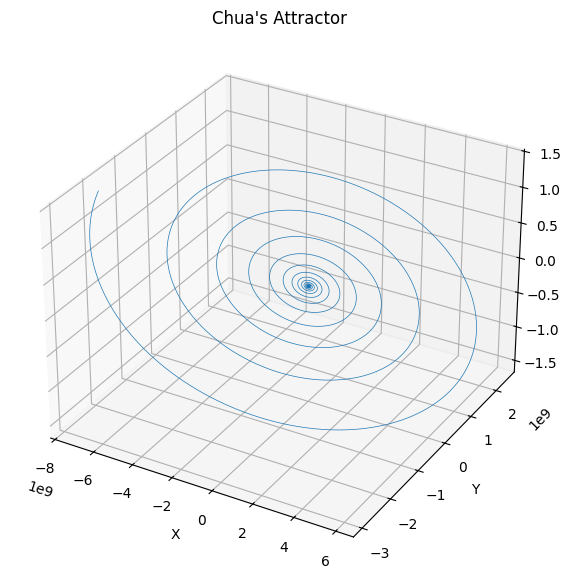

In [15]:
t_span = (0, 70)
t_eval = np.linspace(t_span[0], t_span[1], 70000)   

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [16]:
#####################################################################################################
q = 100
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)



for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 

    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))



(1e-14, 10.0)

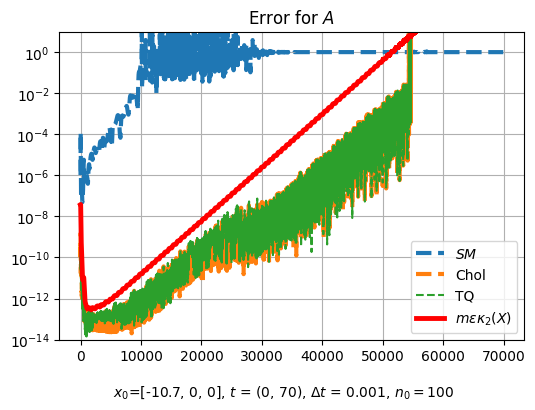

In [17]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e1)

### FIG. 9c)

- $x_0 = [10^{-15}, 0, 0], \Delta t = 10^{-3}, t_{max} = 10, n_0 = 50$

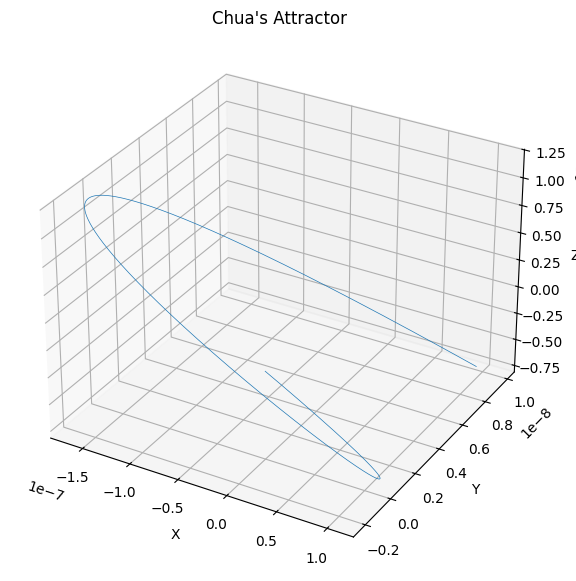

In [18]:
t_span = (0, 10)
t_eval = np.linspace(t_span[0], t_span[1], 10000)   
initial_state=[1e-15,0,0]

sol = solve_ivp(
    chua_system, 
    t_span, 
    initial_state, 
    args=(alpha, beta, m0, m1), 
    t_eval=t_eval,
    method='RK45' 
)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot(sol.y[0], sol.y[1], sol.y[2], lw=0.5)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title("Chua's Attractor")
plt.grid(True)
plt.show()

sol = sol.y
data = np.vstack((sol, sol**2))

del(sol)

(m,n) = data.shape

In [19]:
#####################################################################################################
q = 50
ahead = 0
ord_od = 2

a_sm = []
a_tq = []
a_chol = []
cond_num = []

#######################################################################################################
#####  TQ-sDMD

R, Q = scipy.linalg.rq(data[:,: q], mode="economic") #returns R and Q^T
Gyq = data[:, 1:q+1]@(Q.T)

del(Q)

for k in range(q, n-1):

    Gyq, R = updateYQT(Gyq, R, data[:, k].reshape(-1,1), data[:, k+1].reshape(-1,1), 0,0,tri='U')

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_tq.append(np.linalg.norm(scipy.linalg.solve_triangular(R.T, Gyq.T, lower=True).T-A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od)) #isto kao pinv



############################################################################################################
##          SM-sDMD 


Gyx = data[:, 1:q+1]@(data[:, :q].T)
Gx = data[:, :q]@(data[:, :q].T)
Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")

A_sm = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

del(Gx)



for k in range(q, n-1):
    
    z = Px@(data[:, k].reshape(-1,1))
    gamma = 1/(1+data[:,k].reshape(1,-1)@z)
    A_sm= A_sm + (gamma*(data[:, k+1].reshape(-1,1)-A_sm@(data[:, k].reshape(-1,1))))@z.T
    Px = Px-gamma*(z@z.T) 

    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_sm.append(np.linalg.norm(A_sm-A_batch, ord=ord_od)/np.linalg.norm(A_batch,ord=ord_od))


########################################################################################################
###         Chol-sDMD

Qc, Rc = scipy.linalg.qr(data[:, :q].T, mode="economic")

Achol = scipy.linalg.lstsq(data[:, :q].T, data[:, 1:q+1].T)[0].T

for k in range(q, n-1):
    
    first = scipy.linalg.solve_triangular(Rc.T, data[:, k].reshape(-1,1), lower=True)
    px = scipy.linalg.solve_triangular(Rc, first, lower=False) 

    gamma = 1/(1+first.T@first)
    gamma = gamma[0,0]
    
    Achol = Achol + (gamma*(data[:, k+1].reshape(-1,1)-Achol@(data[:, k].reshape(-1,1))))@px.T
    Rc = R_update(Rc, data[:, k])
    A_batch = scipy.linalg.lstsq(data[:, :k+1].T, data[:, 1:k+2].T)[0].T

    a_chol.append(np.linalg.norm(Achol - A_batch, ord=ord_od)/np.linalg.norm(A_batch, ord=ord_od))
    
    svds = np.linalg.svdvals(data[:, :k])
    cond_num.append(max(svds)/min(svds))



C:\Users\elawi\AppData\Local\Temp\ipykernel_26088\831391260.py:35: LinAlgWarning: Ill-conditioned matrix (rcond=5.48951e-44): result may not be accurate.
  Px = scipy.linalg.solve(Gx, np.eye(Gx.shape[0]), assume_a="pos")


(1e-14, 1e+20)

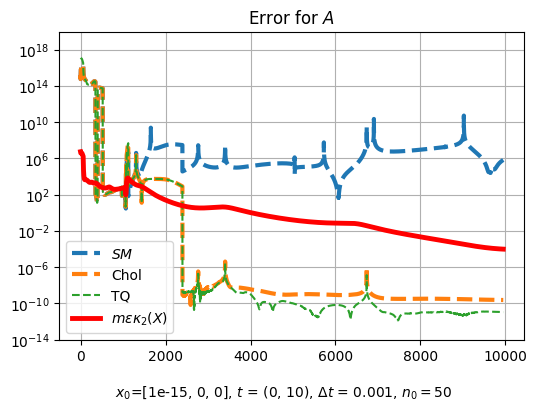

In [24]:
plt.figure(figsize=(6,4))
plt.plot(a_sm, label="$SM$", marker='', ls="--", lw=3)
plt.plot(a_chol, label="Chol", ls="--", marker='', lw=3)
plt.plot(a_tq, label="TQ", ls="--", marker='')
plt.plot((m*eps_double)*np.array(cond_num), label="$m\epsilon \kappa_2(X)$", marker="", lw=3.5, color="red")
plt.grid()
plt.title("Error for $A$")
plt.legend()
plt.figtext(0.5, -0.03, "$x_0$={}, $t$ = {}, $\Delta t$ = {}, $n_0 = {}$ ".format(initial_state, t_span, t_span[1]/len(t_eval), q), ha='center', fontsize=10, weight=500)


plt.yscale('log')
plt.ylim(1e-14, 1e20)